In [5]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import datetime as dt
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df.dropna(subset=['CustomerID'], inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})


rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm[(rfm['Monetary'] < 10000) & (rfm['Frequency'] < 500)]
X = rfm.values 
rfm.head().style.background_gradient(cmap=sns.cubehelix_palette(as_cmap=True))

,Recency,Frequency,Monetary
CustomerID,,,
12347.000000,2,182,4310.000000
12348.000000,75,31,1797.240000
12349.000000,19,73,1757.550000
12350.000000,310,17,334.400000
12352.000000,36,85,2506.040000


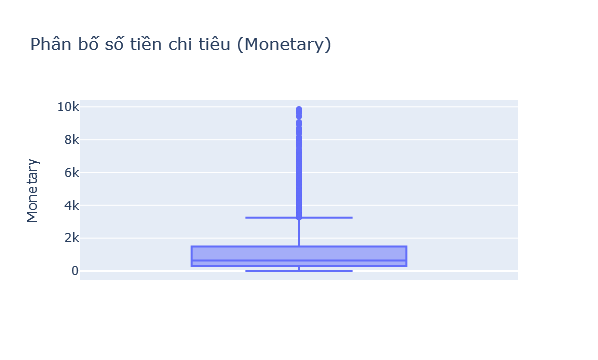

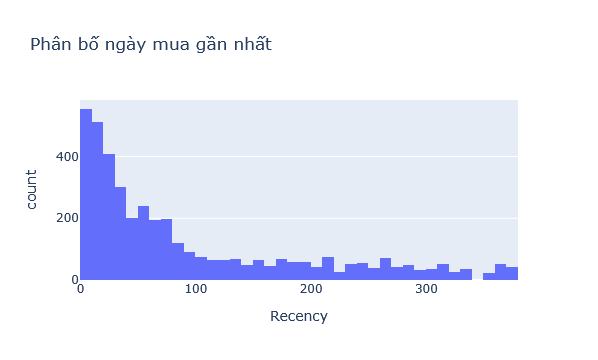

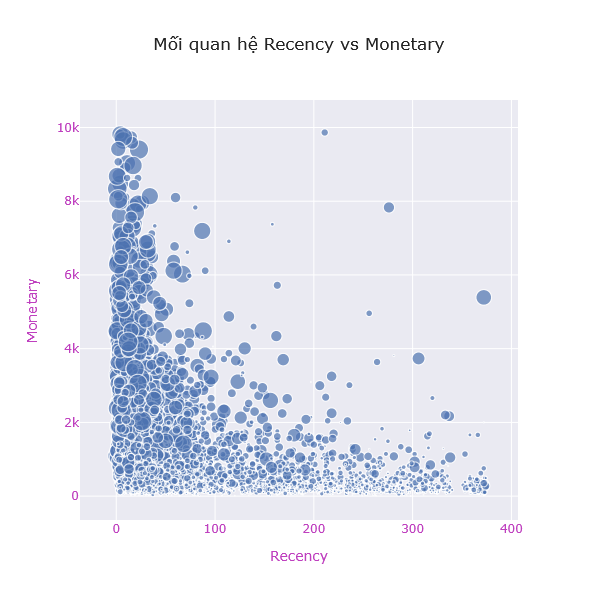

In [7]:
# Phân tích biến Monetary (Tổng tiền) với box-plot
fig = px.box(data_frame=rfm, y='Monetary', title='Phân bố số tiền chi tiêu (Monetary)')
fig.show()

# Phân tích biến Recency (Độ gần đây) với histogram
fig = px.histogram(data_frame=rfm, x='Recency', nbins=50, title='Phân bố ngày mua gần nhất')
fig.show()

# Phân tích 2 biến Recency và Monetary
fig = px.scatter(data_frame=rfm, x='Recency', y='Monetary',
                 size='Frequency', # Kích thước chấm dựa trên tần suất mua
                 template='seaborn',
                 title='Mối quan hệ Recency vs Monetary')
fig.update_layout(width=800, height=600,
                  xaxis=dict(color="#BF40BF"),
                  yaxis=dict(color="#BF40BF"))
fig.show()

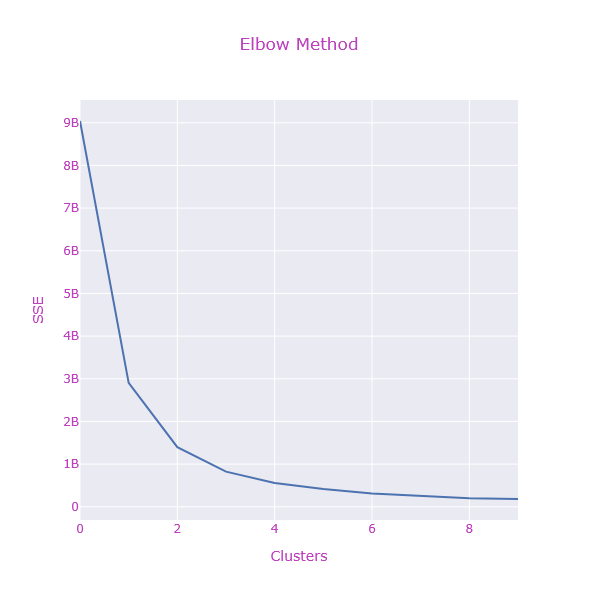

In [9]:
sse = []
# Chạy vòng lặp từ k=1 đến 10 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)


fig = px.line(y=sse, template="seaborn", title='Elbow Method')
fig.update_layout(width=800, height=600,
                  title_font_color="#BF40BF",
                  xaxis=dict(color="#BF40BF", title="Clusters"),
                  yaxis=dict(color="#BF40BF", title="SSE"))
fig.show()

# Dựa vào biểu đồ, độ dốc giảm mạnh ở 3, nên chọn Cluster = 3

In [11]:
kmeans = KMeans(n_clusters=3, 
                init='k-means++', 
                max_iter=300, 
                n_init=10, 
                random_state=0)


clusters = kmeans.fit_predict(X)

print("Đã phân cụm ")

Đã phân cụm 


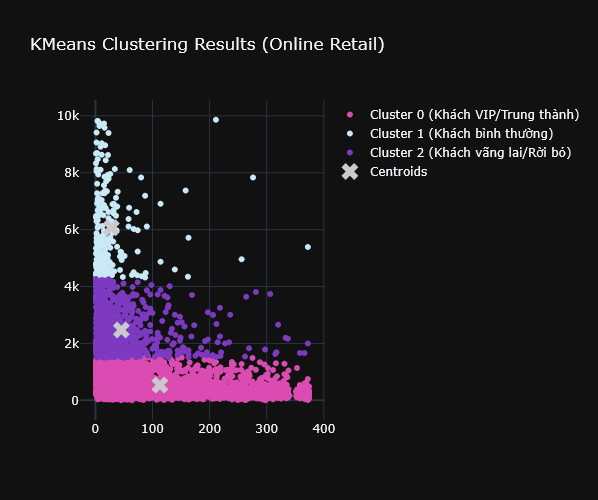

In [13]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X[clusters == 0, 0], y=X[clusters == 0, 2],
    mode='markers', marker_color='#DB4CB2', name='Cluster 0 (Khách VIP/Trung thành)'
))

fig.add_trace(go.Scatter(
    x=X[clusters == 1, 0], y=X[clusters == 1, 2],
    mode='markers', marker_color='#c9e9f6', name='Cluster 1 (Khách bình thường)'
))

fig.add_trace(go.Scatter(
    x=X[clusters == 2, 0], y=X[clusters == 2, 2],
    mode='markers', marker_color='#7D3AC1', name='Cluster 2 (Khách vãng lai/Rời bỏ)'
))

fig.add_trace(go.Scatter(
    x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 2],
    mode='markers', marker_color='#CAC9CD', marker_symbol='x', # Dùng dấu x hoặc kim cương (4)
    marker_size=15, name='Centroids'
))

fig.update_layout(template='plotly_dark', width=1000, 
                  height=500, title='KMeans Clustering Results (Online Retail)')
fig.show()